# Tier 0: reproducing the alpha sweep of Kumar et al. (2024)

**Question.** Does grokking on modular addition, and its control by the laziness parameter alpha, reproduce at the published hyperparameters?

**The published setup.** Kumar et al. (2024), Appendix 8.3, arXiv:2310.06110v3: one hidden layer of width 100, inputs of size 2p from two one-hot codes, outputs of size p, mean squared error, full-batch gradient descent at learning rate 100, p equal to 23, 90 percent of the pairs for training, no weight decay. Their Figure 2(c) sweeps alpha over 0.5, 1, 1.5 and 2 for 100,000 epochs, and grokking arrives later as alpha grows and not at all at alpha 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ntk_lib as L  # training loop, crossings, kernel terms and plot helpers shared by the tier notebooks

L.set_plot_style()

ALPHAS = [0.5, 1.0, 1.5, 2.0]
SEEDS = [0, 1, 2, 3, 4]
STEPS = 100000
TAU = 1e-2  # loss threshold for the pre-registered definition, applied to both losses

# Test accuracy at which the generalisation event is declared; the memorisation event is always train accuracy 1.
TEST_ACC_LEVEL = 1.0

def saved(alpha, seed):
    """True if this seed of the alpha cell is already trained and saved under results/."""
    return (L.RESULTS / (L.cell_name(100, alpha, 0.0, seed) + ".json")).exists()

# Seed 0 of each alpha is always loaded, and trained first if missing; further seeds are used where saved.
runs = {(a, s): L.load_cell(100, a, 0.0, s, STEPS, eval_interval=500)
        for a in ALPHAS for s in SEEDS if s == 0 or saved(a, s)}


## How to read the tables and figures

**Grokking time** is the number of steps between two events: memorisation, when the network gets the training set right, and generalisation, when it gets the held-out test pairs right. Two definitions detect the events differently.

- **Accuracy definition (primary).** Memorisation is the first step at train accuracy 1. Generalisation is the first step at which test accuracy reaches `TEST_ACC_LEVEL`, set in the first code cell.
- **Loss definition.** Both events are the first step at which the loss falls below 0.01. The test loss settles between 0.01 and 0.03 long after accuracy is perfect, so this definition rarely records generalisation within a run.

**Censoring.** If generalisation has not happened when the run ends, the grokking time is known only to exceed the run length minus the memorisation step. Tables write such a bound with a plus sign; figures draw it as a triangle, with the true value above the marker, and a circle for a measured time.

**Dots on curves.** A hollow dot is the memorisation event and a filled dot the generalisation event of that run.


## 1. The two definitions on one run

Alpha 1, seed 0. Left: the two losses with the threshold as a dash-dot line. Right: the two accuracies with the levels 1 and `TEST_ACC_LEVEL`. The shaded band is the grokking time under each definition; an open-ended band means the test event never happened in the run.


Loss definition: memorisation step 7500, generalisation never within the run, grokking time >92500 steps.
Accuracy definition: memorisation step 4500, generalisation step 17000, grokking time 12500 steps.


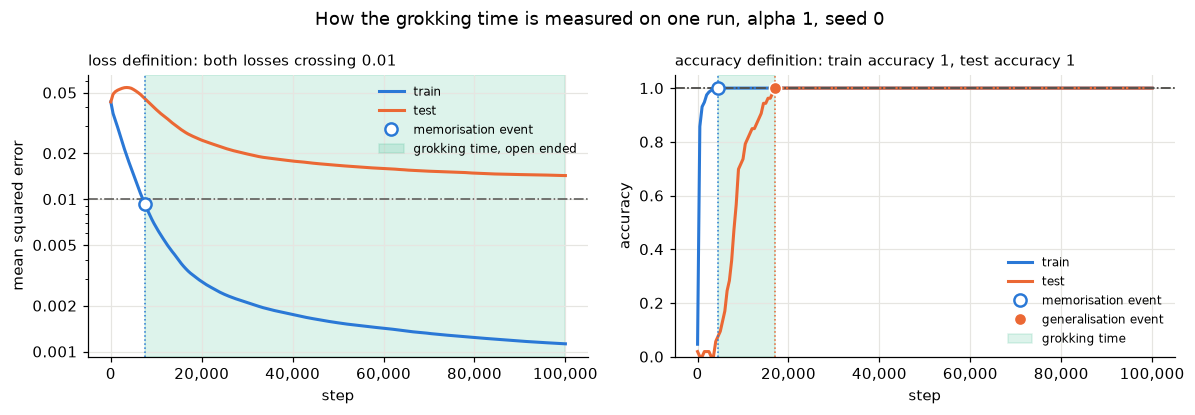

In [2]:
# One run, both definitions side by side, with the two events and the gap between them marked.
fig = L.plot_definitions(runs[(1.0, 0)], tau=TAU, test_level=TEST_ACC_LEVEL,
                         title="How the grokking time is measured on one run, alpha 1, seed 0")


## 2. Grokking time across alpha

One row per alpha: the mean over seeds with the standard deviation in brackets, and the number of censored seeds. A censored seed contributes its lower bound, so a row with censored seeds is itself a lower bound.


In [3]:
def summarise_alpha(definition):
    """Print, for each alpha, the mean and spread over seeds of the two crossings and the grokking time."""
    print(f"{'alpha':>6} {'seeds':>5} {'train crossing':>18} {'test crossing':>18} {'grokking time':>18} {'censored':>9}")
    for a in ALPHAS:
        # One summary per seed; summarise_cell returns the crossings under the chosen definition.
        rows = [L.summarise_cell(runs[(a, s)], definition, TAU, test_level=TEST_ACC_LEVEL) for s in SEEDS if (a, s) in runs]
        cols = []
        for key in ("t_train", "t_test", "t_grok"):
            vals = np.array([r[key] for r in rows if r[key] is not None], float)
            cols.append(f"{vals.mean():>8.0f} ({vals.std(ddof=1):>6.0f})" if len(vals) > 1 else f"{'-':>18}")
        print(f"{a:>6g} {len(rows):>5} {cols[0]:>18} {cols[1]:>18} {cols[2]:>18} {sum(r['censored'] for r in rows):>9}")

print(f"Loss definition, threshold {TAU:g} on both losses:")
summarise_alpha("loss")
print(f"\nAccuracy definition, train accuracy 1 to test accuracy {TEST_ACC_LEVEL:g}:")
summarise_alpha("accuracy")


Loss definition, threshold 0.01 on both losses:
 alpha seeds     train crossing      test crossing      grokking time  censored
   0.5     5      3200 (   274)     19100 (  6959)     15900 (  6795)         0
     1     5      7800 (   758)                  -     92200 (   758)         5
   1.5     5     14300 (  1718)                  -     85700 (  1718)         5
     2     5     25100 (  3732)                  -     74900 (  3732)         5

Accuracy definition, train accuracy 1 to test accuracy 1:
 alpha seeds     train crossing      test crossing      grokking time  censored
   0.5     5      2000 (     0)      5300 (   837)      3300 (   837)         0
     1     5      4300 (   274)     36200 ( 16987)     31900 ( 17115)         0
   1.5     5      7000 (  1369)                  -     93000 (  1369)         5
     2     5      9000 (  2000)                  -     91000 (  2000)         5


## 3. Learning curves, compare Kumar et al. Figure 2

Seed 0 of each alpha. Losses correspond to their Figure 2(c), accuracies and the weight norm to Figure 2(a), where the norm rises from about 150 to about 350. The weight norm does not depend on the grokking-time definition. Hollow and filled dots are the memorisation and generalisation events under the accuracy definition.


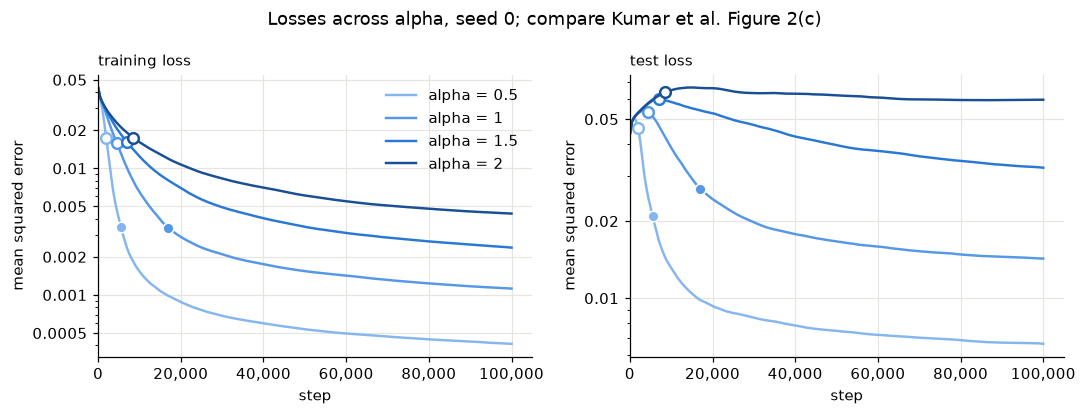

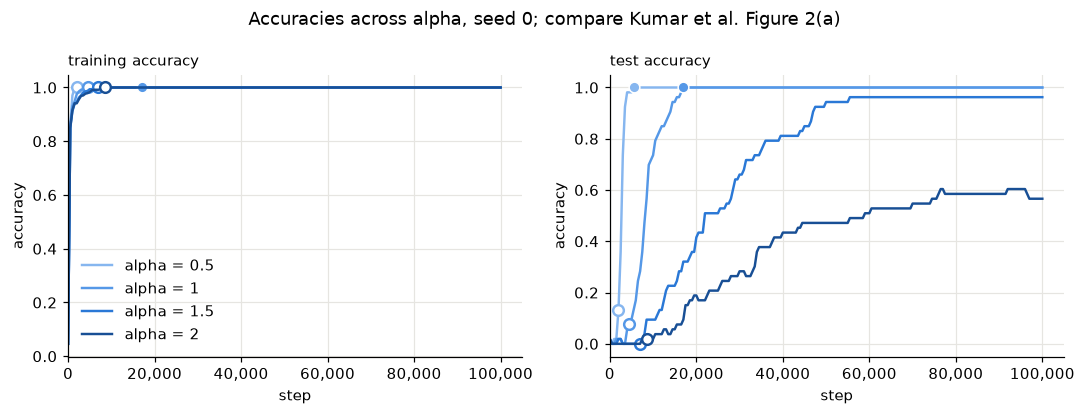

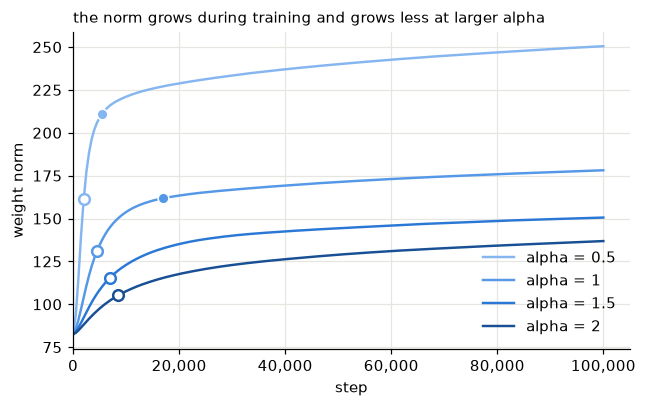

In [4]:
seed0 = [runs[(a, 0)] for a in ALPHAS]
labels = [f"alpha = {a:g}" for a in ALPHAS]
crossings = [L.accuracy_crossings(r, TEST_ACC_LEVEL) for r in seed0]  # the two events of each run, for the dots

# plot_series draws one panel per key with every run overlaid, and marks the events when crossings are given.
fig = L.plot_series(seed0, ["train_loss", "test_loss"], labels, L.RAMP,
                    ["training loss", "test loss"],
                    log_y=("train_loss", "test_loss"), crossings=crossings, log_x=False, mark_train=True,
                    figsize=(10, 3.8), suptitle="Losses across alpha, seed 0; compare Kumar et al. Figure 2(c)")
fig = L.plot_series(seed0, ["train_acc", "test_acc"], labels, L.RAMP,
                    ["training accuracy", "test accuracy"],
                    crossings=crossings, log_x=False, mark_train=True, figsize=(10, 3.8),
                    suptitle="Accuracies across alpha, seed 0; compare Kumar et al. Figure 2(a)")
fig = L.plot_series(seed0, ["weight_norm"], labels, L.RAMP,
                    ["the norm grows during training and grows less at larger alpha"],
                    crossings=crossings, log_x=False, mark_train=True, figsize=(6, 3.8))
fig.axes[0].legend(loc="lower right")


## 4. Grokking time against alpha, all seeds

A circle is a measured grokking time and a triangle a censored lower bound.


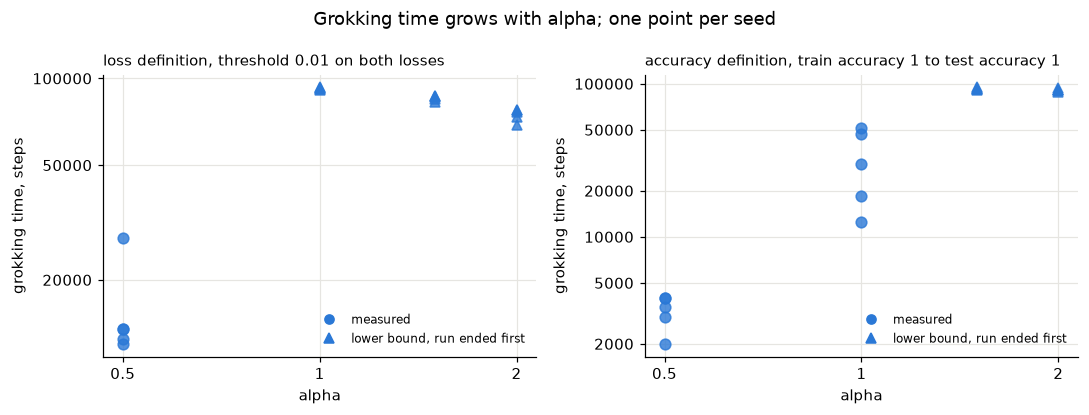

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, definition in zip(axes, ["loss", "accuracy"]):
    for (a, s), run in runs.items():
        row = L.summarise_cell(run, definition, TAU, test_level=TEST_ACC_LEVEL)
        if row["t_grok"] is None:
            continue  # the training event never happened, so there is no grokking time to draw
        ax.plot([a], [row["t_grok"]], "^" if row["censored"] else "o", color=L.BLUE, ms=7, alpha=0.8)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(ALPHAS); ax.set_xticklabels([f"{a:g}" for a in ALPHAS]); ax.minorticks_off()
    ax.set_xlabel("alpha"); ax.set_ylabel("grokking time, steps")
    detail = f", threshold {TAU:g} on both losses" if definition == "loss" else f", train accuracy 1 to test accuracy {TEST_ACC_LEVEL:g}"
    ax.set_title(f"{definition} definition{detail}", loc="left", fontsize=10)
    ax.plot([], [], "o", color=L.BLUE, label="measured")  # legend entries only
    ax.plot([], [], "^", color=L.BLUE, label="lower bound, run ended first")
    ax.legend(fontsize=8, loc="lower right")
    L.tidy_axes(ax)
fig.suptitle("Grokking time grows with alpha; one point per seed")
fig.tight_layout()
